# import Module

In [1]:
import pandas as pd
import pickle
import os
from imblearn.over_sampling import  SMOTE
import numpy as np
from sklearn.preprocessing import StandardScaler , OneHotEncoder
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset , DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt  
import copy
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

Load Dataset

load , normalization , smote , train_test_split 

In [ ]:
df = pd.read_csv(".\\diabetes_prediction_dataset.csv")
print(df.head(10))


x_num = df[["age" , "hypertension", "heart_disease", "bmi", "HbA1c_level" ,"blood_glucose_level"]]
y = df["diabetes"]

x_text = df[["gender" , "smoking_history"]]
ohe = OneHotEncoder(sparse_output=False)
x_text = ohe.fit_transform(x_text)

x = np.concatenate([x_num , x_text], axis=1)

scaler = StandardScaler()
scaler.fit_transform(x)

smote = SMOTE(random_state=42)
x_res , y_res = smote.fit_resample(x , y)

X_train , X_temp , Y_train , Y_temp = train_test_split(x_res , y_res , test_size=0.2)
X_test , X_val , Y_test , Y_val = train_test_split(X_temp , Y_temp , test_size=0.5)

print(X_train.shape , X_test.shape , Y_train.shape , Y_test.shape)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

X_test = np.array(X_test)
Y_test = np.array(Y_test)

X_val = np.array(X_val)
Y_val = np.array(Y_val)


X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

data_tensor_train = TensorDataset(X_train , Y_train)
data_tensor_test = TensorDataset(X_test , Y_test) 
data_tensor_val = TensorDataset(X_val , Y_val)


data_train = DataLoader(data_tensor_train , batch_size=100 , shuffle=True)
data_test =DataLoader(data_tensor_test , batch_size=100)
data_tensor_val =DataLoader(data_tensor_val , batch_size=100)

print("\n" ,y.value_counts()) # The biggest problem 

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   
5  Female  20.0             0              0           never  27.32   
6  Female  44.0             0              0           never  19.31   
7  Female  79.0             0              0         No Info  23.86   
8    Male  42.0             0              0           never  33.64   
9  Female  32.0             0              0           never  27.32   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0            

Feature Importance 

In [3]:
from sklearn.ensemble import GradientBoostingClassifier as skl_GBC
feature_importance = skl_GBC()
feature_importance.fit(X_train , Y_train)
feature = feature_importance.feature_importances_

for i ,f in enumerate(feature):
    print(f"{i} score : {f}")


print(X_train[0:10])

0 score : 0.0826843899497839
1 score : 0.039725866985709214
2 score : 0.009549706829804626
3 score : 0.011453174701637727
4 score : 0.5175354804106356
5 score : 0.2831128283818158
6 score : 0.0036292672635659844
7 score : 0.00924156626624219
8 score : 0.0
9 score : 0.027603504307594333
10 score : 0.0017935109789383441
11 score : 0.0008717358219398254
12 score : 0.003224738569788842
13 score : 0.007804170123486884
14 score : 0.001770059409056661
tensor([[5.3000e+01, 0.0000e+00, 0.0000e+00, 4.2590e+01, 8.8000e+00, 1.4500e+02,
         1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00],
        [3.4000e+01, 0.0000e+00, 0.0000e+00, 2.7140e+01, 3.5000e+00, 2.0000e+02,
         1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 1.0000e+00, 0.0000e+00],
        [4.3000e+01, 0.0000e+00, 0.0000e+00, 2.7320e+01, 5.7000e+00, 1.4500e+02,
         0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+0

# Model

In [9]:
input_dim = X_train.shape[1]

seq_model = nn.Sequential(
    nn.Linear(input_dim , 64),
    nn.ReLU(),

    nn.Linear(64 , 32),
    nn.ReLU(),

    nn.Linear(32 , 16),
    nn.ReLU(),

    nn.Linear(16, 8 ),
    nn.ReLU(),

    nn.Dropout(0.5),
    nn.Linear(8, 1 ),
    nn.Sigmoid()
)


# Train

In [10]:
criterion = nn.BCELoss() 

optimizer = torch.optim.Adam(seq_model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5, min_lr=0.001)

epochs = 100
patience = 10
best_val_loss = float('inf')
best_weights = copy.deepcopy(seq_model.state_dict())
patience_counter = 0

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(epochs):
    seq_model.train()
    train_loss, train_correct = 0.0, 0
    for X_batch, y_batch in data_train:
        optimizer.zero_grad()
        outputs = seq_model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        preds = (outputs > 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        
    train_loss /= len(data_train.dataset)
    train_acc = train_correct / len(data_train.dataset)

    seq_model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in data_tensor_val:
            outputs = seq_model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item() * X_batch.size(0)
            preds = (outputs > 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            
    val_loss /= len(data_tensor_val.dataset)
    val_acc = val_correct / len(data_tensor_val.dataset)
    
    scheduler.step(val_loss)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(seq_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
            
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")
seq_model.load_state_dict(best_weights)

Epoch  10/100 - loss: 0.2767 - acc: 0.8658 - val_loss: 0.2745 - val_acc: 0.8805
Epoch  20/100 - loss: 0.2529 - acc: 0.8765 - val_loss: 0.2216 - val_acc: 0.8949
Epoch  30/100 - loss: 0.2326 - acc: 0.8822 - val_loss: 0.1925 - val_acc: 0.9078

Early stopping triggered at epoch 31


<All keys matched successfully>

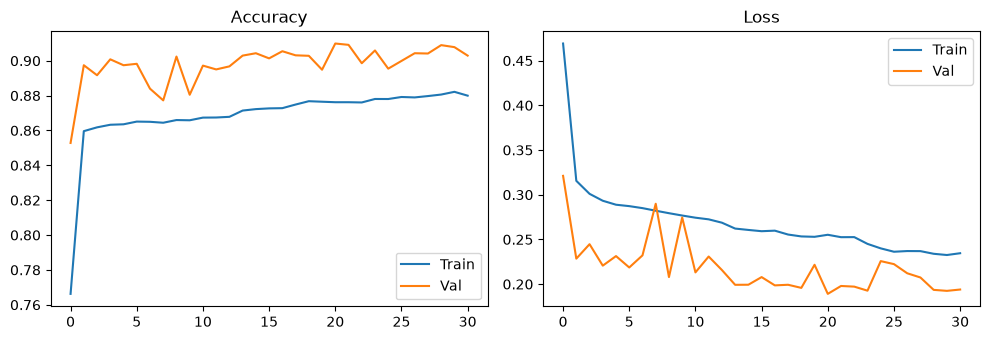

In [11]:
plt.figure(figsize=(10, 3.5))
plt.subplot(1, 2, 1)
plt.plot(history["accuracy"]); plt.plot(history["val_accuracy"])
plt.title("Accuracy"); plt.legend(["Train", "Val"])

plt.subplot(1, 2, 2)
plt.plot(history["loss"]); plt.plot(history["val_loss"])
plt.title("Loss"); plt.legend(["Train", "Val"])
plt.tight_layout(); plt.show()

# Test 

In [12]:
seq_model.eval()
with torch.no_grad():
    y_prob = seq_model(X_test).squeeze().numpy()

y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(Y_test, y_pred)
prec = precision_score(Y_test, y_pred)
rec = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)

print(f"Accuracy: {acc:.4f}  F1: {f1:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}")
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))


Accuracy: 0.9056  F1: 0.9083  Precision: 0.8835  Recall: 0.9346
[[8010 1129]
 [ 599 8562]]
              precision    recall  f1-score   support

 No Diabetes       0.93      0.88      0.90      9139
    Diabetes       0.88      0.93      0.91      9161

    accuracy                           0.91     18300
   macro avg       0.91      0.91      0.91     18300
weighted avg       0.91      0.91      0.91     18300



# Save model

In [14]:
torch.save(seq_model.state_dict(), "model_diabet.pt")

with open("model_diabet_pickle.pkl" , "wb") as f:
    pickle.dump(seq_model ,f )

with open("OneHotEncoder.pkl" , "wb") as f:
    pickle.dump(ohe ,f )

with open("StandardScaler.pkl" , "wb") as f:
    pickle.dump(scaler ,f )

with open("SMOTE.pkl", "wb") as f:
    pickle.dump(smote , f)